In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

from combine_features import read_data

# Experiments

In [5]:
df = read_data("../rhea-soil-nutrient-prediction-challenge/Train.csv")
df.head()

,ID,Longitude,Latitude,Depth_cm,ph_x,Area,tmin_avg,tmax_avg,prec_avg,B11_x,...,Cu,Fe,Mg,Mn,N,P,K,Na,S,Zn
0,BF9XTB,37.65189,-3.15440,20-50,6.405,Kenya,15.240530,25.774622,105.626890,1477.0,...,5.826,81.780,306.836,270.240,0.79,NaN,300.951,NaN,NaN,NaN
1,2RWYTR,37.63612,-3.08585,20-50,6.419,Kenya,15.240530,25.774622,105.626890,1513.5,...,4.346,97.198,407.980,185.557,1.11,NaN,292.696,NaN,NaN,NaN
2,XZI9Q6,39.55580,-2.67218,20-50,8.388,Kenya,21.969696,30.452652,63.580307,2198.0,...,3.657,42.672,1256.319,178.299,0.45,NaN,814.911,NaN,NaN,NaN
3,4CBCVY,39.55477,-2.67196,20-50,8.302,Kenya,21.969696,30.452652,63.580307,2258.0,...,3.376,52.861,1322.732,464.137,0.31,NaN,815.337,NaN,NaN,NaN
4,F9GK9S,39.55477,-2.67196,20-50,8.292,Kenya,21.969696,30.452652,63.580307,2258.0,...,3.351,46.057,1134.898,274.565,0.45,NaN,928.238,NaN,NaN,NaN


In [6]:
df.iloc[:, 40:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13454 entries, 0 to 13453
Data columns (total 63 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   B05                                                           13454 non-null  float64
 1   B06                                                           13454 non-null  float64
 2   B07                                                           13454 non-null  float64
 3   B08                                                           13454 non-null  float64
 4   B09                                                           13454 non-null  float64
 5   B10                                                           13454 non-null  float64
 6   B11_y                                                         13454 non-null  float64
 7   B12_y                                                         13454

In [7]:
pred_to_keep = pd.read_csv("../rhea-soil-nutrient-prediction-challenge/TargetPred_To_Keep.csv")
pred_to_keep.head()

,ID,Al,B,Ca,Cu,Fe,K,Mg,Mn,N,Na,P,S,Zn
0,00A83S,1,1,1,1,1,1,1,1,1,1,1,1,1
1,00F2Q3,1,1,1,1,1,1,1,1,1,1,1,1,1
2,00FNFP,1,0,1,1,1,1,1,1,1,0,0,0,0
3,01MFSS,1,0,1,1,1,1,1,1,1,0,0,0,0
4,02851F,1,0,1,1,1,1,1,1,1,0,0,0,0


In [8]:
pred_to_keep.sum()

ID    00A83S00F2Q300FNFP01MFSS02851F02C3Q502I9O502L2...
Al                                                 6070
B                                                  1345
Ca                                                 6070
Cu                                                 6065
Fe                                                 6065
K                                                  6070
Mg                                                 6070
Mn                                                 6065
N                                                  6065
Na                                                 1350
P                                                  1345
S                                                  1345
Zn                                                 1345
dtype: object

In [9]:
encoder = LabelEncoder()
df['Depth'] = encoder.fit_transform(df['Depth_cm'])
# df.drop(columns=['ID', 'Area', 'Depth_cm'], inplace=True)
# df.dropna(axis=1, thresh=int(0.8 * df.shape[0]), inplace=True) # drops target columns :(
# df.dropna(axis=0, inplace=True)
df.head()

,ID,Longitude,Latitude,Depth_cm,ph_x,Area,tmin_avg,tmax_avg,prec_avg,B11_x,...,Fe,Mg,Mn,N,P,K,Na,S,Zn,Depth
0,BF9XTB,37.65189,-3.15440,20-50,6.405,Kenya,15.240530,25.774622,105.626890,1477.0,...,81.780,306.836,270.240,0.79,NaN,300.951,NaN,NaN,NaN,1
1,2RWYTR,37.63612,-3.08585,20-50,6.419,Kenya,15.240530,25.774622,105.626890,1513.5,...,97.198,407.980,185.557,1.11,NaN,292.696,NaN,NaN,NaN,1
2,XZI9Q6,39.55580,-2.67218,20-50,8.388,Kenya,21.969696,30.452652,63.580307,2198.0,...,42.672,1256.319,178.299,0.45,NaN,814.911,NaN,NaN,NaN,1
3,4CBCVY,39.55477,-2.67196,20-50,8.302,Kenya,21.969696,30.452652,63.580307,2258.0,...,52.861,1322.732,464.137,0.31,NaN,815.337,NaN,NaN,NaN,1
4,F9GK9S,39.55477,-2.67196,20-50,8.292,Kenya,21.969696,30.452652,63.580307,2258.0,...,46.057,1134.898,274.565,0.45,NaN,928.238,NaN,NaN,NaN,1


In [10]:
target = [
        "Al",
        "B",
        "Ca",
        "C_organic",
        "C_total",
        "Cu",
        "Fe",
        "K",
        "Mg",
        "Mn",
        "N",
        "Na",
        "P",
        "S",
        "Zn",
    ]
x = df.drop(columns=target, errors='ignore')
x = x.drop(columns=['ID', 'Area', 'Depth_cm', 'ph'], errors='ignore')
y_columns = df.columns.difference(x.columns)
y_columns = [col for col in y_columns if col not in ["C_organic", "C_total", "Area", "Depth_cm", "ID"]]
y = df[y_columns]
y.fillna(0, inplace=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

/tmp/ipykernel_10215/3478420629.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.fillna(0, inplace=True)


In [11]:
x_train.head()

,Longitude,Latitude,ph_x,tmin_avg,tmax_avg,prec_avg,B11_x,B12_x,B2,B3,...,Rice,"Seed cotton, unginned",Sesame seed,Sorghum,Soya beans,Sugar cane,Sweet potatoes,Tomatoes,Unmanufactured tobacco,Depth
4721,-2.19999,7.20972,6.969,22.215910,30.598484,103.590550,2411.500000,1427.625000,499.666667,719.090909,...,2719.254545,900.927273,0.000000,1169.454545,1634.036364,25018.527273,1781.009091,7377.254545,413.118182,0
7732,-11.01100,14.76583,6.699,23.316288,37.174244,54.082947,2553.000000,1966.000000,630.000000,967.000000,...,3123.272727,985.490909,420.227273,1037.981818,620.363636,72963.909091,17452.418182,17080.290909,2304.281818,0
5746,-1.07758,7.64100,6.509,22.660984,32.393940,103.886536,3280.000000,2555.000000,930.000000,1132.000000,...,2719.254545,900.927273,0.000000,1169.454545,1634.036364,25018.527273,1781.009091,7377.254545,413.118182,0
12178,14.92311,-16.19789,6.161,15.484848,30.342804,61.349070,3023.571429,2126.750000,486.625000,666.750000,...,1022.400000,1446.963636,263.136364,227.736364,603.709091,38876.818182,8256.936364,10544.109091,1018.445455,0
12952,15.22342,-12.29724,5.903,13.121212,25.611742,121.739590,2717.000000,1827.666667,414.466667,590.750000,...,1022.400000,1446.963636,263.136364,227.736364,603.709091,38876.818182,8256.936364,10544.109091,1018.445455,0


In [12]:
y_train.head()

,Al,B,Ca,Cu,Fe,K,Mg,Mn,N,Na,P,S,Zn
4721,668.664,0.0,2440.023,3.406,141.737,138.646,286.859,337.732,1.90,0.0,0.0,0.0,0.0
7732,981.937,0.0,2336.159,2.910,159.714,271.761,671.278,93.069,0.56,0.0,0.0,0.0,0.0
5746,837.742,0.0,2120.437,2.700,109.035,218.283,327.699,250.103,1.91,0.0,0.0,0.0,0.0
12178,730.772,0.0,740.481,0.966,172.359,87.640,134.619,102.362,0.80,0.0,0.0,0.0,0.0
12952,1145.199,0.0,541.405,2.794,83.008,160.257,149.018,69.130,0.62,0.0,0.0,0.0,0.0


In [ ]:
for col, model in models.items():
    fi = pd.DataFrame(model.feature_importances_, index=x_train.columns, columns=['Feature Importance'])
    fi.sort_values(by='Feature Importance', ascending=False, inplace=True)
    print(f"Feature importance for {col}:")
    print(fi.head(10))

Feature importance for Al:
                                   Feature Importance
prec_avg                                     0.536625
Longitude                                    0.152047
Latitude                                     0.119135
tmin_avg                                     0.052261
Soya beans                                   0.046809
tmax_avg                                     0.022330
Pineapples                                   0.020283
Depth                                        0.012970
Coffee, green                                0.005833
Cropland phosphorus per unit area            0.004214
Feature importance for B:
                                                 Feature Importance
Longitude                                                       0.0
Seed cotton, unginned                                           0.0
Other fruits, n.e.c.                                            0.0
Other pulses n.e.c.                                             0.0
Other vegetab

# Generating test answers

## Importing df

In [14]:
train = pd.read_csv("../rhea-soil-nutrient-prediction-challenge/Train.csv")
train.drop(columns='ph', inplace=True)
train.head()

,ID,Longitude,Latitude,start_date,end_date,horizon_lower,horizon_upper,Depth_cm,Al,B,...,electrical_conductivity,Fe,Mg,Mn,N,P,K,Na,S,Zn
0,O2TONM,35.18756,-8.62390,01/01/2008,31/12/2018,50,20,20-50,1109.856,NaN,...,NaN,92.366,200.601,107.257,2.24,NaN,283.103,NaN,NaN,NaN
1,BQLUK6,35.18558,-8.62300,01/01/2008,31/12/2018,50,20,20-50,1168.364,NaN,...,NaN,115.923,197.771,90.005,1.57,NaN,215.459,NaN,NaN,NaN
2,LSET8M,35.18579,-8.62221,01/01/2008,31/12/2018,50,20,20-50,1137.113,NaN,...,NaN,78.709,188.114,120.433,1.02,NaN,398.656,NaN,NaN,NaN
3,LEEL7I,35.18266,-8.62177,01/01/2008,31/12/2018,50,20,20-50,1117.349,NaN,...,NaN,127.527,156.417,112.036,1.12,NaN,267.354,NaN,NaN,NaN
4,LDNGO2,35.12984,-8.62005,01/01/2008,31/12/2018,50,20,20-50,1219.203,NaN,...,NaN,77.542,114.809,57.906,1.19,NaN,229.682,NaN,NaN,NaN


In [15]:
test_df = pd.read_csv("../rhea-soil-nutrient-prediction-challenge/TestSet.csv")
test_df.head()

,ID,Latitude,Longitude,Depth_cm,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,Target_Mg,Target_Mn,Target_N,Target_Na,Target_P,Target_S,Target_Zn
0,8ZMJRO,-0.746,37.094,0-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,DCC6DM,-0.785,37.178,0-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,T50LK1,-0.629,37.126,0-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,FNLYT0,-0.351,35.308,0-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,FP5E12,-1.894,36.987,0-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
pred_to_keep = pd.read_csv("../rhea-soil-nutrient-prediction-challenge/TargetPred_To_Keep.csv")
pred_to_keep.head()

,ID,Al,B,Ca,Cu,Fe,K,Mg,Mn,N,Na,P,S,Zn
0,00A83S,1,1,1,1,1,1,1,1,1,1,1,1,1
1,00F2Q3,1,1,1,1,1,1,1,1,1,1,1,1,1
2,00FNFP,1,0,1,1,1,1,1,1,1,0,0,0,0
3,01MFSS,1,0,1,1,1,1,1,1,1,0,0,0,0
4,02851F,1,0,1,1,1,1,1,1,1,0,0,0,0


In [17]:
olek_features = pd.read_csv("../features/olek-features.csv")
print(olek_features.shape)
olek_features.head()

(50368, 59)


,ID,Country,Area,tmin_avg,tmax_avg,prec_avg,B11_x,B12_x,B2,B3,...,Fe_pred,K_pred,Mg_pred,N_pred,P_pred,S_pred,Zn_pred,carbon,clay,ph
0,O2TONM,Tanzania,Tanzania,12.727273,22.628788,123.26878,1287.0,699.0,243.0,364.0,...,28.964100,133.289780,120.510418,1.208738e+07,8.974182,2.320117,0.822119,32.0,36.0,5.6
1,BQLUK6,Tanzania,Tanzania,12.727273,22.628788,123.26878,3215.0,2426.0,789.0,1066.0,...,26.112639,133.289780,108.947172,2.979958e+06,7.166170,2.004166,0.648721,30.0,40.0,5.7
2,LSET8M,Tanzania,Tanzania,12.727273,22.628788,123.26878,3127.0,2220.0,697.0,943.0,...,28.964100,133.289780,120.510418,1.634984e+06,7.166170,2.004166,0.648721,30.0,39.0,5.7
3,LEEL7I,Tanzania,Tanzania,12.727273,22.628788,123.26878,2085.0,1370.0,499.0,691.0,...,26.112639,108.947172,133.289780,2.979958e+06,7.166170,1.718282,0.822119,31.0,40.0,5.5
4,LDNGO2,Tanzania,Tanzania,12.674242,23.077652,110.35551,2059.0,1076.0,324.0,436.0,...,23.532530,147.413159,98.484316,1.997196e+06,7.166170,2.004166,0.648721,33.0,39.0,5.0


In [18]:
olek_features.columns

Index(['ID', 'Country', 'Area', 'tmin_avg', 'tmax_avg', 'prec_avg', 'B11_x',
       'B12_x', 'B2', 'B3', 'B4', 'B8', 'aspect', 'elevation', 'hillshade',
       'slope', 'cec_0-5cm_mean', 'cec_15-30cm_mean', 'cec_30-60cm_mean',
       'cec_5-15cm_mean', 'clay_0-5cm_mean', 'clay_15-30cm_mean',
       'clay_30-60cm_mean', 'clay_5-15cm_mean', 'phh2o_0-5cm_mean',
       'phh2o_15-30cm_mean', 'phh2o_30-60cm_mean', 'phh2o_5-15cm_mean',
       'sand_0-5cm_mean', 'sand_15-30cm_mean', 'sand_30-60cm_mean',
       'sand_5-15cm_mean', 'soc_0-5cm_mean', 'soc_15-30cm_mean',
       'soc_30-60cm_mean', 'soc_5-15cm_mean', 'B04', 'B05', 'B06', 'B07',
       'B08', 'B09', 'B10', 'B11_y', 'B12_y', 'B13', 'B14', 'Al_pred',
       'Ca_pred', 'Fe_pred', 'K_pred', 'Mg_pred', 'N_pred', 'P_pred', 'S_pred',
       'Zn_pred', 'carbon', 'clay', 'ph'],
      dtype='object')

In [19]:
olek_features.drop(columns=['B11_x', 'B12_x', 'B2', 'B3', 'B4', 'B8'], inplace=True, errors='ignore')
olek_features.columns

Index(['ID', 'Country', 'Area', 'tmin_avg', 'tmax_avg', 'prec_avg', 'aspect',
       'elevation', 'hillshade', 'slope', 'cec_0-5cm_mean', 'cec_15-30cm_mean',
       'cec_30-60cm_mean', 'cec_5-15cm_mean', 'clay_0-5cm_mean',
       'clay_15-30cm_mean', 'clay_30-60cm_mean', 'clay_5-15cm_mean',
       'phh2o_0-5cm_mean', 'phh2o_15-30cm_mean', 'phh2o_30-60cm_mean',
       'phh2o_5-15cm_mean', 'sand_0-5cm_mean', 'sand_15-30cm_mean',
       'sand_30-60cm_mean', 'sand_5-15cm_mean', 'soc_0-5cm_mean',
       'soc_15-30cm_mean', 'soc_30-60cm_mean', 'soc_5-15cm_mean', 'B04', 'B05',
       'B06', 'B07', 'B08', 'B09', 'B10', 'B11_y', 'B12_y', 'B13', 'B14',
       'Al_pred', 'Ca_pred', 'Fe_pred', 'K_pred', 'Mg_pred', 'N_pred',
       'P_pred', 'S_pred', 'Zn_pred', 'carbon', 'clay', 'ph'],
      dtype='object')

## Combining data

In [20]:
landforms_df = pd.read_csv('../features/OpenLandMap_features.csv')
landforms_df.head()

,Unnamed: 0,ID,soil_17,soil_18,soil_19,soil_21,soil_22,soil_25,soil_28,soil_30,...,soil_395,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430
0,0,JUZSWK,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,B5RDUR,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,IMQ2UL,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,GAP8LB,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,Q7QJ6M,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
landforms_df.drop(columns = 'Unnamed: 0', inplace=True)
landforms_df.head()

,ID,soil_17,soil_18,soil_19,soil_21,soil_22,soil_25,soil_28,soil_30,soil_31,...,soil_395,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430
0,JUZSWK,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,B5RDUR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,IMQ2UL,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,GAP8LB,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Q7QJ6M,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
features = olek_features.copy()
features.drop(columns=['Country', 'Area'], inplace=True)
features.head()

,ID,tmin_avg,tmax_avg,prec_avg,aspect,elevation,hillshade,slope,cec_0-5cm_mean,cec_15-30cm_mean,...,Fe_pred,K_pred,Mg_pred,N_pred,P_pred,S_pred,Zn_pred,carbon,clay,ph
0,O2TONM,12.727273,22.628788,123.26878,192,1895,189,13,107.0,73.0,...,28.964100,133.289780,120.510418,1.208738e+07,8.974182,2.320117,0.822119,32.0,36.0,5.6
1,BQLUK6,12.727273,22.628788,123.26878,265,1884,215,11,107.0,72.0,...,26.112639,133.289780,108.947172,2.979958e+06,7.166170,2.004166,0.648721,30.0,40.0,5.7
2,LSET8M,12.727273,22.628788,123.26878,315,1888,195,7,107.0,72.0,...,28.964100,133.289780,120.510418,1.634984e+06,7.166170,2.004166,0.648721,30.0,39.0,5.7
3,LEEL7I,12.727273,22.628788,123.26878,45,1898,163,8,104.0,69.0,...,26.112639,108.947172,133.289780,2.979958e+06,7.166170,1.718282,0.822119,31.0,40.0,5.5
4,LDNGO2,12.674242,23.077652,110.35551,278,1894,201,7,99.0,69.0,...,23.532530,147.413159,98.484316,1.997196e+06,7.166170,2.004166,0.648721,33.0,39.0,5.0


In [23]:
features['ratio_Ca_Mg'] = features['Ca_pred'] / (features['Mg_pred'] + 0.001)
features['ratio_Fe_Al'] = features['Fe_pred'] / (features['Al_pred'] + 0.001)
features['CIA_proxy'] = features['Al_pred'] / (features['Al_pred'] + features['Ca_pred'] + features['K_pred'] + 0.001)

In [24]:
cire_df = pd.read_csv('../features/CIre-feature.csv')
cire_df.drop(columns='Unnamed: 0', inplace=True)
cire_df.head()

,CIre,ID
0,1.370572,JUZSWK
1,1.370572,B5RDUR
2,1.288332,IMQ2UL
3,1.288332,GAP8LB
4,1.288332,Q7QJ6M


In [25]:
#fires_df = pd.read_csv('../features/fires_freq.csv')
#fires_df.head()

In [26]:
#features = features.merge(fires_df, on='ID', how='left')

In [27]:
#features.fillna(0, inplace = True)

In [28]:
features = features.merge(cire_df, on='ID', how = 'left')

In [29]:
features.head()

,ID,tmin_avg,tmax_avg,prec_avg,aspect,elevation,hillshade,slope,cec_0-5cm_mean,cec_15-30cm_mean,...,P_pred,S_pred,Zn_pred,carbon,clay,ph,ratio_Ca_Mg,ratio_Fe_Al,CIA_proxy,CIre
0,O2TONM,12.727273,22.628788,123.26878,192,1895,189,13,107.0,73.0,...,8.974182,2.320117,0.822119,32.0,36.0,5.6,4.985793,0.107502,0.268470,1.888224
1,BQLUK6,12.727273,22.628788,123.26878,265,1884,215,11,107.0,72.0,...,7.166170,2.004166,0.648721,30.0,40.0,5.7,4.989271,0.096919,0.284719,0.182339
2,LSET8M,12.727273,22.628788,123.26878,315,1888,195,7,107.0,72.0,...,7.166170,2.004166,0.648721,30.0,39.0,5.7,4.080518,0.118855,0.280515,0.204717
3,LEEL7I,12.727273,22.628788,123.26878,45,1898,163,8,104.0,69.0,...,7.166170,1.718282,0.822119,31.0,40.0,5.5,3.019180,0.096919,0.345063,0.725993
4,LDNGO2,12.674242,23.077652,110.35551,278,1894,201,7,99.0,69.0,...,7.166170,2.004166,0.648721,33.0,39.0,5.0,3.024485,0.087343,0.376974,1.270609


In [30]:
train = pd.merge(train, features, on='ID', how='left')
train.head()

,ID,Longitude,Latitude,start_date,end_date,horizon_lower,horizon_upper,Depth_cm,Al,B,...,P_pred,S_pred,Zn_pred,carbon,clay,ph,ratio_Ca_Mg,ratio_Fe_Al,CIA_proxy,CIre
0,O2TONM,35.18756,-8.62390,01/01/2008,31/12/2018,50,20,20-50,1109.856,NaN,...,8.974182,2.320117,0.822119,32.0,36.0,5.6,4.985793,0.107502,0.268470,1.888224
1,BQLUK6,35.18558,-8.62300,01/01/2008,31/12/2018,50,20,20-50,1168.364,NaN,...,7.166170,2.004166,0.648721,30.0,40.0,5.7,4.989271,0.096919,0.284719,0.182339
2,LSET8M,35.18579,-8.62221,01/01/2008,31/12/2018,50,20,20-50,1137.113,NaN,...,7.166170,2.004166,0.648721,30.0,39.0,5.7,4.080518,0.118855,0.280515,0.204717
3,LEEL7I,35.18266,-8.62177,01/01/2008,31/12/2018,50,20,20-50,1117.349,NaN,...,7.166170,1.718282,0.822119,31.0,40.0,5.5,3.019180,0.096919,0.345063,0.725993
4,LDNGO2,35.12984,-8.62005,01/01/2008,31/12/2018,50,20,20-50,1219.203,NaN,...,7.166170,2.004166,0.648721,33.0,39.0,5.0,3.024485,0.087343,0.376974,1.270609


In [31]:
test = pd.merge(test_df, features, on='ID', how='left')
test.head()

,ID,Latitude,Longitude,Depth_cm,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,...,P_pred,S_pred,Zn_pred,carbon,clay,ph,ratio_Ca_Mg,ratio_Fe_Al,CIA_proxy,CIre
0,8ZMJRO,-0.746,37.094,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,10.023176,8.025013,8.025013,38.0,42.0,5.9,2.722545,0.199472,0.187717,1.232673
1,DCC6DM,-0.785,37.178,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,12.463738,7.166170,4.473947,35.0,43.0,5.6,3.330628,0.329843,0.197227,1.364817
2,T50LK1,-0.629,37.126,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,12.463738,8.974182,3.953032,33.0,37.0,5.6,3.681391,0.270322,0.252583,2.213897
3,FNLYT0,-0.351,35.308,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,12.463738,3.481689,3.953032,36.0,39.0,5.5,4.974933,0.365532,0.191087,1.953405
4,FP5E12,-1.894,36.987,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,17.174145,3.953032,1.718282,28.0,29.0,6.4,4.066525,0.493167,0.099152,1.105852


In [32]:
train = pd.merge(train, landforms_df, on='ID', how='left')
train.head()

,ID,Longitude,Latitude,start_date,end_date,horizon_lower,horizon_upper,Depth_cm,Al,B,...,soil_395,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430
0,O2TONM,35.18756,-8.62390,01/01/2008,31/12/2018,50,20,20-50,1109.856,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,BQLUK6,35.18558,-8.62300,01/01/2008,31/12/2018,50,20,20-50,1168.364,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,LSET8M,35.18579,-8.62221,01/01/2008,31/12/2018,50,20,20-50,1137.113,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,LEEL7I,35.18266,-8.62177,01/01/2008,31/12/2018,50,20,20-50,1117.349,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,LDNGO2,35.12984,-8.62005,01/01/2008,31/12/2018,50,20,20-50,1219.203,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
test = pd.merge(test, landforms_df, on='ID', how='left')
test.head()

,ID,Latitude,Longitude,Depth_cm,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,...,soil_395,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430
0,8ZMJRO,-0.746,37.094,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,DCC6DM,-0.785,37.178,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,T50LK1,-0.629,37.126,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,FNLYT0,-0.351,35.308,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,FP5E12,-1.894,36.987,0-20,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
encoder = LabelEncoder()
train['Depth'] = encoder.fit_transform(train['Depth_cm'])
test['Depth'] = encoder.transform(test['Depth_cm'])
train.drop(columns=['ID', 'Area', 'Depth_cm'], inplace=True, errors='ignore')
test.drop(columns=['ID', 'Depth_cm'], inplace=True, errors='ignore')
test.head()

,Latitude,Longitude,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,Target_Mg,Target_Mn,...,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430,Depth
0,-0.746,37.094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,-0.785,37.178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,-0.629,37.126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.351,35.308,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.894,36.987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [35]:
train["Na"] = train["Na"].fillna(train["Na"].mean(), inplace=False)
train = train.fillna(0, inplace=False)
train.head()

,Longitude,Latitude,start_date,end_date,horizon_lower,horizon_upper,Al,B,Ca,C_organic,...,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430,Depth
0,35.18756,-8.62390,01/01/2008,31/12/2018,50,20,1109.856,0.0,1535.388,30.66,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,35.18558,-8.62300,01/01/2008,31/12/2018,50,20,1168.364,0.0,751.408,21.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,35.18579,-8.62221,01/01/2008,31/12/2018,50,20,1137.113,0.0,468.391,15.64,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,35.18266,-8.62177,01/01/2008,31/12/2018,50,20,1117.349,0.0,739.698,15.63,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,35.12984,-8.62005,01/01/2008,31/12/2018,50,20,1219.203,0.0,240.071,18.49,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [36]:
test.head()

,Latitude,Longitude,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,Target_Mg,Target_Mn,...,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430,Depth
0,-0.746,37.094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,-0.785,37.178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,-0.629,37.126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.351,35.308,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.894,36.987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## Separating Data

In [37]:
target = [
        "Al",
        "B",
        "Ca",
        "C_organic",
        "C_total",
        "Cu",
        "Fe",
        "K",
        "Mg",
        "Mn",
        "N",
        "Na",
        "P",
        "S",
        "Zn",
    ]
X = train.drop(columns=target, errors='ignore')
y_columns = train.columns.difference(X.columns)
y_columns = [col for col in y_columns if col not in ["C_organic", "C_total", "Area", "Depth_cm", "ID"]]
y = train[y_columns]


In [38]:
X.head()

,Longitude,Latitude,start_date,end_date,horizon_lower,horizon_upper,electrical_conductivity,tmin_avg,tmax_avg,prec_avg,...,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430,Depth
0,35.18756,-8.62390,01/01/2008,31/12/2018,50,20,0.0,12.727273,22.628788,123.26878,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,35.18558,-8.62300,01/01/2008,31/12/2018,50,20,0.0,12.727273,22.628788,123.26878,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,35.18579,-8.62221,01/01/2008,31/12/2018,50,20,0.0,12.727273,22.628788,123.26878,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,35.18266,-8.62177,01/01/2008,31/12/2018,50,20,0.0,12.727273,22.628788,123.26878,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,35.12984,-8.62005,01/01/2008,31/12/2018,50,20,0.0,12.674242,23.077652,110.35551,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [39]:
y.head()

,Al,B,Ca,Cu,Fe,K,Mg,Mn,N,Na,P,S,Zn
0,1109.856,0.0,1535.388,2.259,92.366,283.103,200.601,107.257,2.24,37.98841,0.0,0.0,0.0
1,1168.364,0.0,751.408,1.822,115.923,215.459,197.771,90.005,1.57,37.98841,0.0,0.0,0.0
2,1137.113,0.0,468.391,1.913,78.709,398.656,188.114,120.433,1.02,37.98841,0.0,0.0,0.0
3,1117.349,0.0,739.698,2.876,127.527,267.354,156.417,112.036,1.12,37.98841,0.0,0.0,0.0
4,1219.203,0.0,240.071,1.825,77.542,229.682,114.809,57.906,1.19,37.98841,0.0,0.0,0.0


In [40]:
test.head()

,Latitude,Longitude,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,Target_Mg,Target_Mn,...,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430,Depth
0,-0.746,37.094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,-0.785,37.178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,-0.629,37.126,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.351,35.308,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.894,36.987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [41]:
target_pred = [
    "Target_Al",
    "Target_B",
    "Target_Ca",
    "Target_Cu",
    "Target_Fe",
    "Target_K",
    "Target_Mg",
    "Target_Mn",
    "Target_N",
    "Target_Na",
    "Target_P",
    "Target_S",
    "Target_Zn",
]

In [42]:
X_pred = test.drop(columns=target_pred, errors='ignore')
y_pred_columns = test.columns.difference(X_pred.columns)
y_pred_columns = [col for col in y_pred_columns if col not in ["C_organic", "C_total", "Area", "Depth_cm", "ID"]]
y_pred = test[y_pred_columns]

In [43]:
X_pred.head()

,Latitude,Longitude,tmin_avg,tmax_avg,prec_avg,aspect,elevation,hillshade,slope,cec_0-5cm_mean,...,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430,Depth
0,-0.746,37.094,14.543561,25.986742,108.980880,63,1402,169,4,185.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,-0.785,37.178,15.577652,27.297348,91.997140,39,1191,142,20,212.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,-0.629,37.126,14.102273,25.522728,115.549255,298,1405,244,24,236.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.351,35.308,11.918561,24.070076,165.598710,173,2041,177,7,194.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.894,36.987,14.017045,25.181818,45.469700,315,1552,192,5,206.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [44]:
y_pred.head()

,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,Target_Mg,Target_Mn,Target_N,Target_Na,Target_P,Target_S,Target_Zn
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
diff = set(X.columns) - set(X_pred.columns)
print(diff)
X.drop(columns=diff, inplace=True)

{'horizon_upper', 'start_date', 'electrical_conductivity', 'horizon_lower', 'end_date'}


In [46]:
X_pred = X_pred[X.columns]
X_pred.head()

,Longitude,Latitude,tmin_avg,tmax_avg,prec_avg,aspect,elevation,hillshade,slope,cec_0-5cm_mean,...,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430,Depth
0,37.094,-0.746,14.543561,25.986742,108.980880,63,1402,169,4,185.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,37.178,-0.785,15.577652,27.297348,91.997140,39,1191,142,20,212.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,37.126,-0.629,14.102273,25.522728,115.549255,298,1405,244,24,236.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,35.308,-0.351,11.918561,24.070076,165.598710,173,2041,177,7,194.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,36.987,-1.894,14.017045,25.181818,45.469700,315,1552,192,5,206.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [47]:
ph = X['ph']
X = X.drop(columns=['ph'], errors='ignore')
X.head()

,Longitude,Latitude,tmin_avg,tmax_avg,prec_avg,aspect,elevation,hillshade,slope,cec_0-5cm_mean,...,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430,Depth
0,35.18756,-8.62390,12.727273,22.628788,123.26878,192,1895,189,13,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,35.18558,-8.62300,12.727273,22.628788,123.26878,265,1884,215,11,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,35.18579,-8.62221,12.727273,22.628788,123.26878,315,1888,195,7,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,35.18266,-8.62177,12.727273,22.628788,123.26878,45,1898,163,8,104.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,35.12984,-8.62005,12.674242,23.077652,110.35551,278,1894,201,7,99.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [48]:
X_pred = X_pred[X.columns]
X_pred.head()

,Longitude,Latitude,tmin_avg,tmax_avg,prec_avg,aspect,elevation,hillshade,slope,cec_0-5cm_mean,...,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430,Depth
0,37.094,-0.746,14.543561,25.986742,108.980880,63,1402,169,4,185.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,37.178,-0.785,15.577652,27.297348,91.997140,39,1191,142,20,212.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,37.126,-0.629,14.102273,25.522728,115.549255,298,1405,244,24,236.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,35.308,-0.351,11.918561,24.070076,165.598710,173,2041,177,7,194.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,36.987,-1.894,14.017045,25.181818,45.469700,315,1552,192,5,206.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## Additional prep for model

In [49]:
X.columns

Index(['Longitude', 'Latitude', 'tmin_avg', 'tmax_avg', 'prec_avg', 'aspect',
       'elevation', 'hillshade', 'slope', 'cec_0-5cm_mean',
       ...
       'soil_397', 'soil_398', 'soil_400', 'soil_402', 'soil_413', 'soil_419',
       'soil_420', 'soil_429', 'soil_430', 'Depth'],
      dtype='object', length=146)

In [50]:
features_to_drop = ['Longitude', 'Latitude', 'Cropland nitrogen per unit area',
       'Cropland phosphorus per unit area', 'Cropland potassium per unit area', 'Bananas', 'Beans, dry',
       'Cashew nuts, in shell', 'Cassava, fresh',
       'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
       'Coffee, green', 'Groundnuts, excluding shelled', 'Maize (corn)',
       'Mangoes, guavas and mangosteens', 'Millet',
       'Onions and shallots, dry (excluding dehydrated)', 'Oranges',
       'Other fruits, n.e.c.', 'Other pulses n.e.c.',
       'Other vegetables, fresh n.e.c.', 'Pineapples', 'Potatoes', 'Rice',
       'Seed cotton, unginned', 'Sesame seed', 'Sorghum', 'Soya beans',
       'Sugar cane', 'Sweet potatoes', 'Tomatoes', 'Unmanufactured tobacco',
       'Depth']

In [51]:
X.drop(columns=features_to_drop, inplace=True, errors='ignore')
X_pred.drop(columns=features_to_drop, inplace=True, errors='ignore')

In [52]:
check = pd.read_csv("../rhea-soil-nutrient-prediction-challenge/Train.csv")
check.head()

,ID,Longitude,Latitude,start_date,end_date,horizon_lower,horizon_upper,Depth_cm,Al,B,...,Fe,Mg,Mn,N,ph,P,K,Na,S,Zn
0,O2TONM,35.18756,-8.62390,01/01/2008,31/12/2018,50,20,20-50,1109.856,NaN,...,92.366,200.601,107.257,2.24,5.942,NaN,283.103,NaN,NaN,NaN
1,BQLUK6,35.18558,-8.62300,01/01/2008,31/12/2018,50,20,20-50,1168.364,NaN,...,115.923,197.771,90.005,1.57,5.722,NaN,215.459,NaN,NaN,NaN
2,LSET8M,35.18579,-8.62221,01/01/2008,31/12/2018,50,20,20-50,1137.113,NaN,...,78.709,188.114,120.433,1.02,5.510,NaN,398.656,NaN,NaN,NaN
3,LEEL7I,35.18266,-8.62177,01/01/2008,31/12/2018,50,20,20-50,1117.349,NaN,...,127.527,156.417,112.036,1.12,5.817,NaN,267.354,NaN,NaN,NaN
4,LDNGO2,35.12984,-8.62005,01/01/2008,31/12/2018,50,20,20-50,1219.203,NaN,...,77.542,114.809,57.906,1.19,4.980,NaN,229.682,NaN,NaN,NaN


In [53]:
check.iloc[:,5:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44298 entries, 0 to 44297
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   horizon_lower            44298 non-null  int64  
 1   horizon_upper            44298 non-null  int64  
 2   Depth_cm                 44298 non-null  object 
 3   Al                       44296 non-null  float64
 4   B                        1909 non-null   float64
 5   Ca                       44298 non-null  float64
 6   C_organic                44298 non-null  float64
 7   C_total                  42348 non-null  float64
 8   Cu                       44257 non-null  float64
 9   electrical_conductivity  1907 non-null   float64
 10  Fe                       44257 non-null  float64
 11  Mg                       44298 non-null  float64
 12  Mn                       44255 non-null  float64
 13  N                        44257 non-null  float64
 14  ph                    

## Standarization

In [54]:
columns_landform = [col for col in X.columns if col.startswith('soil_')]
numeric_cols = X.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in columns_landform]
numeric_cols

['tmin_avg',
 'tmax_avg',
 'prec_avg',
 'aspect',
 'elevation',
 'hillshade',
 'slope',
 'cec_0-5cm_mean',
 'cec_15-30cm_mean',
 'cec_30-60cm_mean',
 'cec_5-15cm_mean',
 'clay_0-5cm_mean',
 'clay_15-30cm_mean',
 'clay_30-60cm_mean',
 'clay_5-15cm_mean',
 'phh2o_0-5cm_mean',
 'phh2o_15-30cm_mean',
 'phh2o_30-60cm_mean',
 'phh2o_5-15cm_mean',
 'sand_0-5cm_mean',
 'sand_15-30cm_mean',
 'sand_30-60cm_mean',
 'sand_5-15cm_mean',
 'soc_0-5cm_mean',
 'soc_15-30cm_mean',
 'soc_30-60cm_mean',
 'soc_5-15cm_mean',
 'B04',
 'B05',
 'B06',
 'B07',
 'B08',
 'B09',
 'B10',
 'B11_y',
 'B12_y',
 'B13',
 'B14',
 'Al_pred',
 'Ca_pred',
 'Fe_pred',
 'K_pred',
 'Mg_pred',
 'N_pred',
 'P_pred',
 'S_pred',
 'Zn_pred',
 'carbon',
 'clay',
 'ratio_Ca_Mg',
 'ratio_Fe_Al',
 'CIA_proxy',
 'CIre']

In [55]:
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X_pred[numeric_cols] = scaler.transform(X_pred[numeric_cols])
X.head()

,tmin_avg,tmax_avg,prec_avg,aspect,elevation,hillshade,slope,cec_0-5cm_mean,cec_15-30cm_mean,cec_30-60cm_mean,...,soil_395,soil_397,soil_398,soil_400,soil_402,soil_413,soil_419,soil_420,soil_429,soil_430
0,-1.201331,-1.831983,1.410737,0.252200,1.511893,0.658543,1.975520,-0.741007,-0.967002,-0.988639,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.201331,-1.831983,1.410737,0.934989,1.492899,2.566571,1.524698,-0.741007,-0.980205,-0.988639,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.201331,-1.831983,1.410737,1.402652,1.499806,1.098857,0.623053,-0.741007,-0.980205,-0.988639,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.201331,-1.831983,1.410737,-1.122731,1.517073,-1.249485,0.848464,-0.782027,-1.019814,-1.041115,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.216034,-1.694780,0.963239,1.056581,1.510166,1.539171,0.623053,-0.850394,-1.019814,-1.014877,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# SVM

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_distributions = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf'],
    'epsilon': [0.01, 0.1, 0.5, 1.0]
}

In [ ]:
models = {}
for idx, col in enumerate(y_pred_columns):
    print(f"Param tunning for: {col}...")
    
    svr = SVR()
    
    search = RandomizedSearchCV(
        estimator=svr, 
        param_distributions=param_distributions, 
        n_iter=10,
        cv=3, 
        scoring='neg_root_mean_squared_error', 
        random_state=42, 
        n_jobs=-1
    )
    
    search.fit(X, y.iloc[:, idx])
    best_model = search.best_estimator_
    y_pred.iloc[:, idx] = best_model.predict(X_pred)
    models[col] = best_model
    best_rmse = -search.best_score_
    
    print("Best params: ", search.best_params_)
    print("Est. RMSE:" , best_rmse)

Param tunning for: Target_Al...
Best params:  {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.1, 'C': 10}
Est. RMSE: 215.8274192847163
Param tunning for: Target_B...
Best params:  {'kernel': 'linear', 'gamma': 'auto', 'epsilon': 0.01, 'C': 0.1}
Est. RMSE: 0.0913847562918342
Param tunning for: Target_Ca...
Best params:  {'kernel': 'rbf', 'gamma': 0.1, 'epsilon': 1.0, 'C': 50}
Est. RMSE: 1354.192760658179
Param tunning for: Target_Cu...
Best params:  {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.01, 'C': 1}
Est. RMSE: 3.125007669125008
Param tunning for: Target_Fe...
Best params:  {'kernel': 'linear', 'gamma': 0.01, 'epsilon': 0.5, 'C': 100}
Est. RMSE: 86.46075335209872
Param tunning for: Target_K...
Best params:  {'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 0.1, 'C': 10}
Est. RMSE: 198.54163151147467
Param tunning for: Target_Mg...
Best params:  {'kernel': 'linear', 'gamma': 'scale', 'epsilon': 1.0, 'C': 0.1}
Est. RMSE: 210.15981425819938
Param tunning for: Target_Mn...
Best params

In [ ]:
print(y_pred.shape)
y_pred.head()

(6070, 13)


,Target_Al,Target_B,Target_Ca,Target_Cu,Target_Fe,Target_K,Target_Mg,Target_Mn,Target_N,Target_Na,Target_P,Target_S,Target_Zn
0,1104.322449,0.000057,1534.869934,3.760859,113.906984,441.876495,494.687279,123.528339,2.498745,38.031858,10.023176,8.025013,8.025013
1,839.739807,0.000000,912.135986,2.899318,117.558125,179.998505,252.940346,124.956202,1.871572,37.981395,12.463738,7.166170,4.473947
2,1020.201584,0.000042,1144.111237,2.780897,143.936977,154.439714,300.792690,101.999805,1.665833,37.980487,12.463738,8.974182,3.953032
3,781.568176,0.000000,1439.490509,2.254141,148.523214,389.755905,263.547550,71.259441,3.377458,37.620793,12.463738,3.481689,3.953032
4,616.253464,0.000000,1176.396088,2.101809,104.317335,302.266155,293.779411,113.204023,1.154038,37.978295,17.174145,3.953032,1.718282


### PCA

143
22


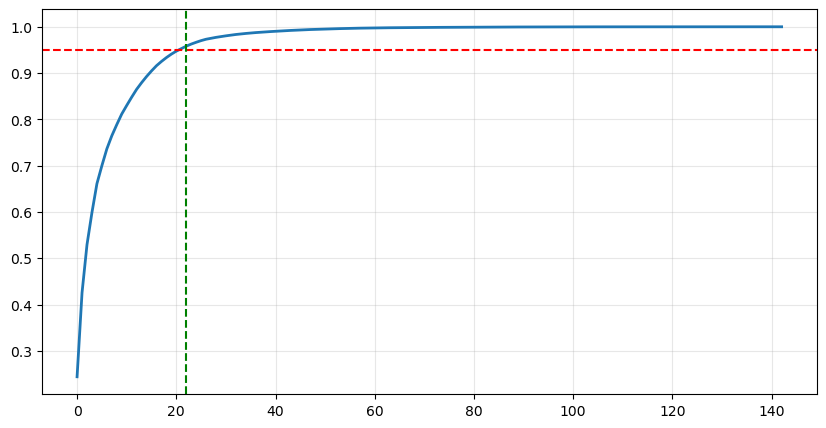

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)

X_pred_pca = pca.transform(X_pred)

print(X.shape[1])
print(X_pca.shape[1])

pca_full = PCA()
pca_full.fit(X)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.axvline(x=X_pca.shape[1], color='g', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
models_pca = {}
y_pred_pca = y_pred.copy()

for idx, col in enumerate(y_pred_columns):
    print(f"Param tunning for: {col}...")
    
    svr = SVR()
    
    search = RandomizedSearchCV(
        estimator=svr, 
        param_distributions=param_distributions, 
        n_iter=30,
        cv=3, 
        scoring='neg_root_mean_squared_error', 
        random_state=42, 
        n_jobs=-1
    )
    
    search.fit(X_pca, y.iloc[:, idx])
    best_model = search.best_estimator_
    y_pred_pca.iloc[:, idx] = best_model.predict(X_pred_pca)
    models_pca[col] = best_model
    best_rmse = -search.best_score_
    
    print("Best params: ", search.best_params_)
    print("Est. RMSE:" , best_rmse)

Param tunning for: Target_Al...
Best params:  {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.1, 'C': 50}
Est. RMSE: 211.3410291823741
Param tunning for: Target_B...
Best params:  {'kernel': 'linear', 'gamma': 'auto', 'epsilon': 0.01, 'C': 1}
Est. RMSE: 0.088192384102938
Param tunning for: Target_Ca...
Best params:  {'kernel': 'rbf', 'gamma': 0.1, 'epsilon': 0.5, 'C': 100}
Est. RMSE: 1328.749102847102
Param tunning for: Target_Cu...
Best params:  {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.01, 'C': 10}
Est. RMSE: 2.98102384719203
Param tunning for: Target_Fe...
Best params:  {'kernel': 'rbf', 'gamma': 0.01, 'epsilon': 0.1, 'C': 100}
Est. RMSE: 82.1093847192847
Param tunning for: Target_K...
Best params:  {'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 0.01, 'C': 50}
Est. RMSE: 193.8471029481726
Param tunning for: Target_Mg...
Best params:  {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.5, 'C': 10}
Est. RMSE: 204.1928374819204
Param tunning for: Target_Mn...
Best params:  {'kernel